In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


plt.rcParams['figure.figsize'] = (8, 6)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Praktikum/Praktikum12/Data/BreastCancer.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [14]:

df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

x = df_clean.drop(columns=['diagnosis'])
y_raw = df_clean['diagnosis']


le = LabelEncoder()
y = le.fit_transform(y_raw)
target_names = le.classes_ # ['B', 'M']

print('Shape x:', x.shape)
print('Shape y:', y.shape)
print('Target classes:', target_names)

Shape x: (569, 30)
Shape y: (569,)
Target classes: ['B' 'M']


In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Shape x_train:', x_train.shape)
print('Shape x_test:', x_test.shape)

Shape x_train: (455, 30)
Shape x_test: (114, 30)


In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [17]:
print("\n--- Training SVM TANPA PCA ---")
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(x_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(x_test_scaled)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

print('Akurasi tanpa PCA:', acc_no_pca)
print(classification_report(y_test, y_pred_no_pca, target_names=target_names))


--- Training SVM TANPA PCA ---
Akurasi tanpa PCA: 0.9736842105263158
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Shape x_train_pca: (455, 3)
Variance ratio tiap komponen: [0.44593522 0.18545255 0.09584641]
Total variance (3 komponen): 0.7272341886241546


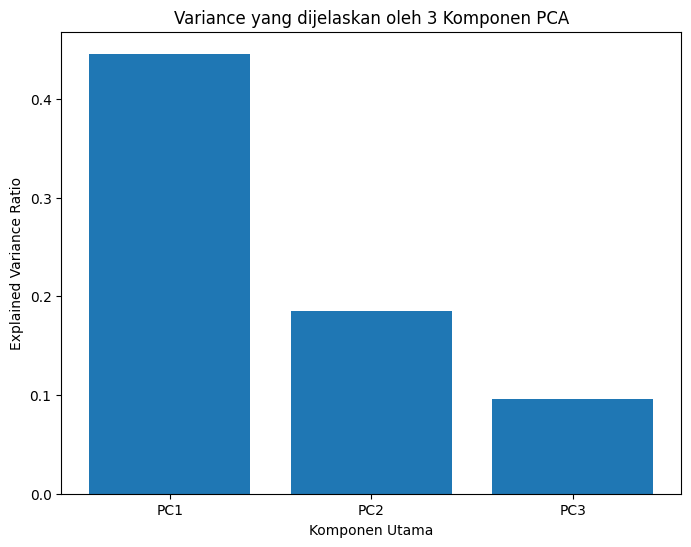

In [18]:
pca = PCA(n_components=3)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print('Shape x_train_pca:', x_train_pca.shape)

# Cek Variance Ratio
explained_var = pca.explained_variance_ratio_
print('Variance ratio tiap komponen:', explained_var)
print('Total variance (3 komponen):', sum(explained_var))

# Plot Variance Ratio
plt.figure()
plt.bar(['PC1', 'PC2', 'PC3'], explained_var)
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance yang dijelaskan oleh 3 Komponen PCA')
plt.show()

In [19]:
print("\n--- Training SVM DENGAN PCA ---")
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(x_train_pca, y_train)

y_pred_pca = svm_pca.predict(x_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print('Akurasi dengan PCA:', acc_pca)
print(classification_report(y_test, y_pred_pca, target_names=target_names))


--- Training SVM DENGAN PCA ---
Akurasi dengan PCA: 0.956140350877193
              precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



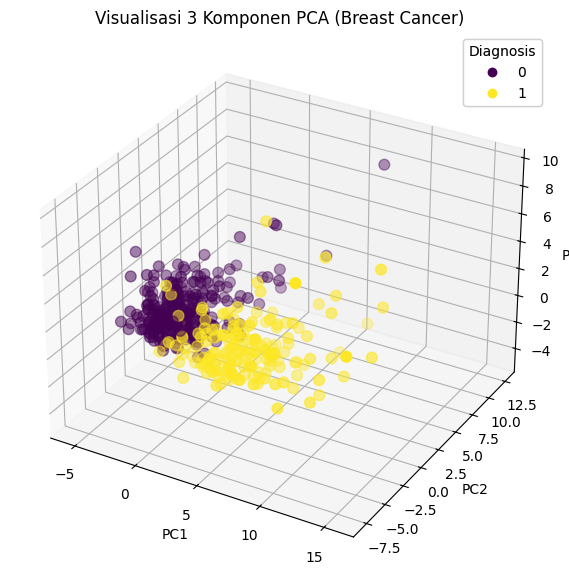

In [20]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot 3D
scatter = ax.scatter(x_train_pca[:, 0], x_train_pca[:, 1], x_train_pca[:, 2],
                     c=y_train, cmap='viridis', s=60)

ax.set_title('Visualisasi 3 Komponen PCA (Breast Cancer)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Menambahkan legenda
legend1 = ax.legend(*scatter.legend_elements(), title="Diagnosis")
ax.add_artist(legend1)
plt.show()


Perbandingan Model:
            Model  Jumlah Fitur   Akurasi  Variansi Total PCA
0   SVM tanpa PCA            30  0.973684                 NaN
1  SVM dengan PCA             3  0.956140            0.727234


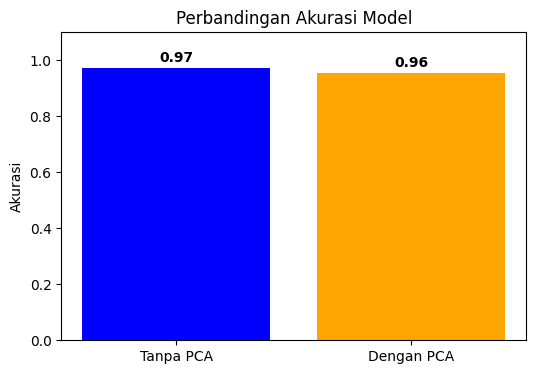

In [21]:
comparison = pd.DataFrame({
    'Model': ['SVM tanpa PCA', 'SVM dengan PCA'],
    'Jumlah Fitur': [x_train_scaled.shape[1], x_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi Total PCA': [None, sum(explained_var)]
})

print("\nPerbandingan Model:")
print(comparison)

# Plot Perbandingan Akurasi
plt.figure(figsize=(6, 4))
plt.bar(['Tanpa PCA', 'Dengan PCA'], [acc_no_pca, acc_pca], color=['blue', 'orange'])
plt.title('Perbandingan Akurasi Model')
plt.ylabel('Akurasi')
plt.ylim(0, 1.1)

for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.show()

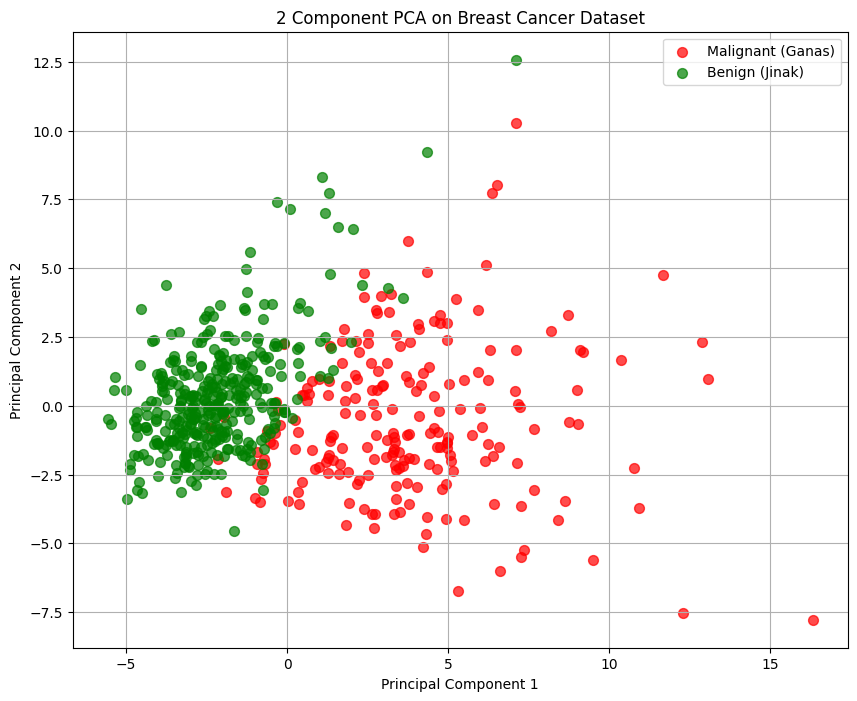

In [22]:
plt.figure(figsize=(10, 8))
targets = ['M', 'B'] # M: Ganas, B: Jinak
colors = ['r', 'g']  # Merah untuk Ganas, Hijau untuk Jinak

for target, color in zip(targets, colors):
    indicesToKeep = pca_df['diagnosis'] == target
    plt.scatter(pca_df.loc[indicesToKeep, 'Principal Component 1'],
                pca_df.loc[indicesToKeep, 'Principal Component 2'],
                c=color, s=50, alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2 Component PCA on Breast Cancer Dataset')
plt.legend(['Malignant (Ganas)', 'Benign (Jinak)'])
plt.grid(True)
plt.show()